In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import model_layers

In [2]:
with open("names.txt", "r") as f:
    words = f.read().splitlines()

In [3]:
chars = ["."] + sorted(list(set("".join(words))))
stoi, itos = {}, {}
for i, char in enumerate(chars):
    stoi[char] = i
    itos[i] = char

vocab_size = len(stoi)

In [35]:
block_size = 3

def build_dataset(words):
    X, Y = [], []

    for word in words:
        context = [0] * block_size
        for ch in word + ".":
            idx = stoi[ch]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1: n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182332, 3]) torch.Size([182332])
torch.Size([22862, 3]) torch.Size([22862])
torch.Size([22952, 3]) torch.Size([22952])


In [36]:
n_embed = 10
n_hidden = 100

C = torch.randn(vocab_size, n_embed)
layers = [
    model_layers.Linear(n_embed * block_size, n_hidden), model_layers.BatchNorm1d(n_hidden), model_layers.Tanh(),
    model_layers.Linear(            n_hidden, n_hidden), model_layers.BatchNorm1d(n_hidden), model_layers.Tanh(),
    model_layers.Linear(            n_hidden, n_hidden), model_layers.BatchNorm1d(n_hidden), model_layers.Tanh(),
    model_layers.Linear(            n_hidden, n_hidden), model_layers.BatchNorm1d(n_hidden), model_layers.Tanh(),
    model_layers.Linear(            n_hidden, n_hidden), model_layers.BatchNorm1d(n_hidden), model_layers.Tanh(),
    model_layers.Linear(            n_hidden, vocab_size), model_layers.BatchNorm1d(vocab_size)

]

with torch.no_grad():
    # layers[-1].weight *= 0.1 # make the last layer less confident
    layers[-1].gamma *= 0.1 # make the last layer less confident
    for layer in layers[:-1]:
        if isinstance(layer, model_layers.Linear):
            layer.weight *= 5 / 3 # apply gain on the other layers

parameters = [C]  + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True


47551


In [37]:
max_steps = 200_000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):

    # create minibatch
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    # forward pass
    emb = C[Xb] # (batch_size X context_window X embed_dim)
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100_000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10_000 == 0:
        print(f"{i:7d}/{max_steps:7d}: {loss.item():.4f}")
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr * p.grad.std() / p.data.std()).log10().item() for p in parameters])

    if i >= 1000:
        break

      0/ 200000: 3.2797


layer 2 (Tanh): mean +0.00, std 0.62, saturated 3.19%
layer 5 (Tanh): mean -0.00, std 0.63, saturated 3.09%
layer 8 (Tanh): mean -0.00, std 0.64, saturated 2.72%
layer 11 (Tanh): mean +0.01, std 0.64, saturated 2.34%
layer 14 (Tanh): mean +0.00, std 0.64, saturated 2.53%


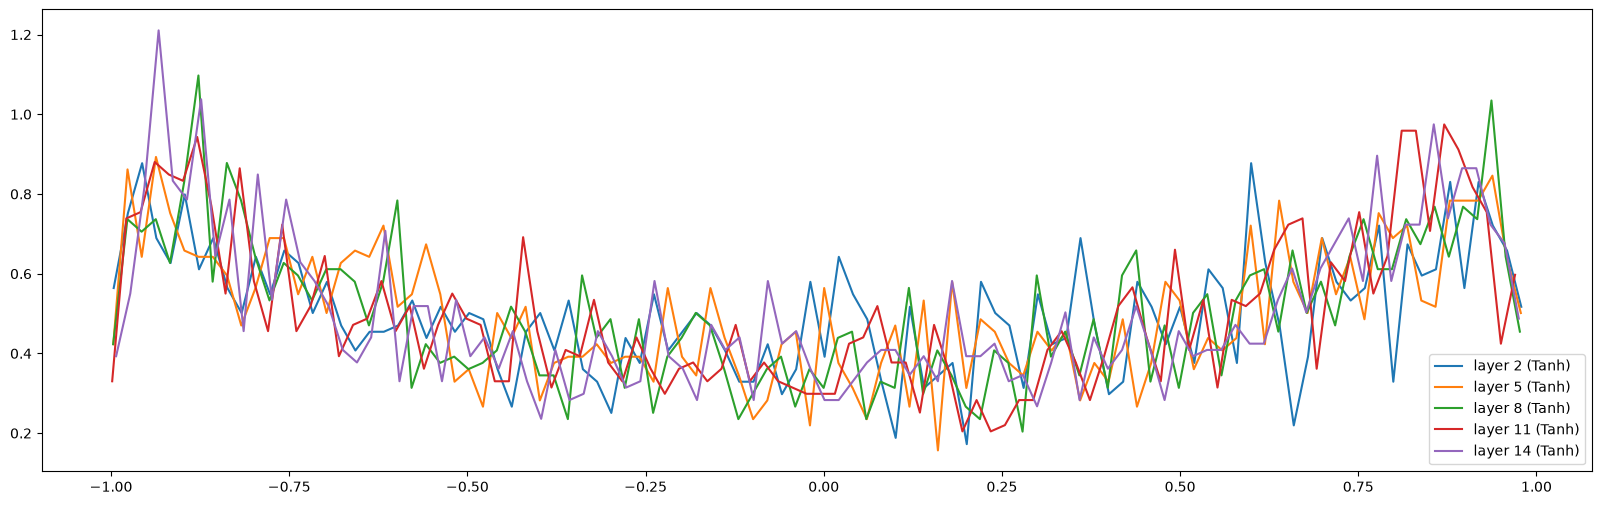

In [38]:
plt.figure(figsize=(20, 6))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, model_layers.Tanh):
        t = layer.out
        print(f"layer {i} ({layer.__class__.__name__}): mean {t.mean():+.2f}, std {t.std():.2f}, saturated {(t.abs() > 0.97).float().mean() * 100:.2f}%")
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);

layer 2 (Tanh): mean -0.0000, std 0.0045, saturated 0.00%
layer 5 (Tanh): mean +0.0000, std 0.0036, saturated 0.00%
layer 8 (Tanh): mean -0.0000, std 0.0033, saturated 0.00%
layer 11 (Tanh): mean -0.0000, std 0.0030, saturated 0.00%
layer 14 (Tanh): mean -0.0000, std 0.0029, saturated 0.00%


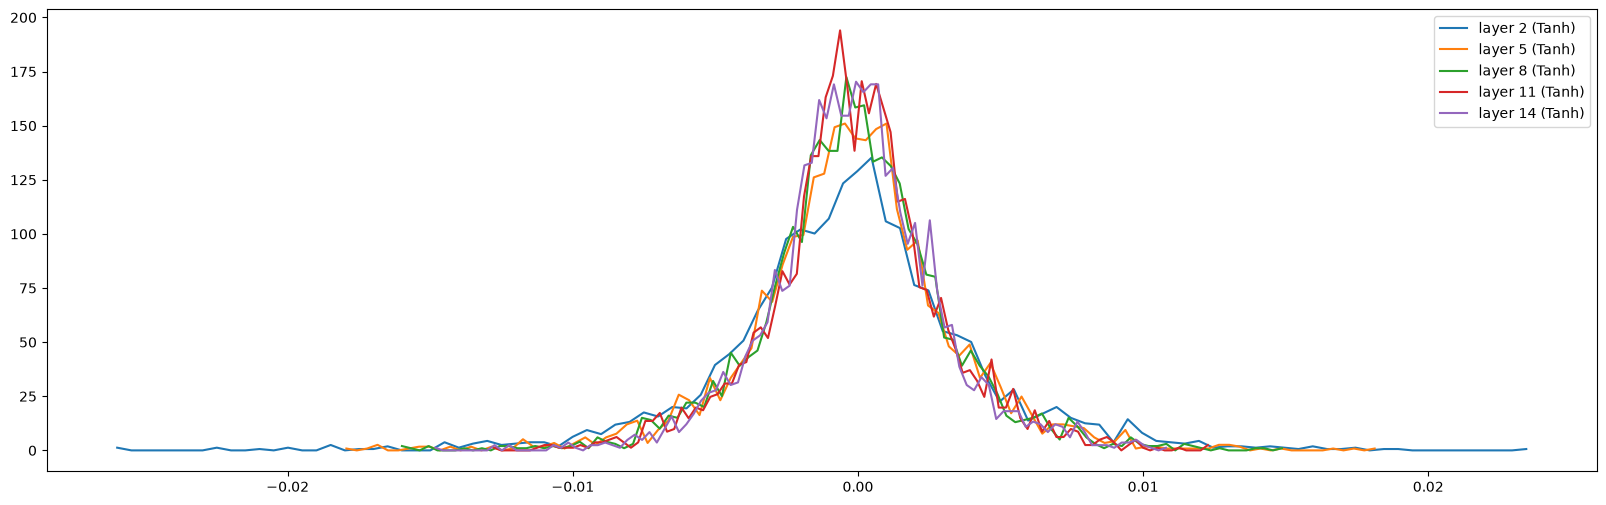

In [39]:
plt.figure(figsize=(20, 6))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, model_layers.Tanh):
        t = layer.out.grad
        print(f"layer {i} ({layer.__class__.__name__}): mean {t.mean():+.4f}, std {t.std():.4f}, saturated {(t.abs() > 0.97).float().mean() * 100:.2f}%")
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);

weight (27, 10) | mean -3.7252903539730653e-10 | std 0.014186759479343891 | grad:data ratio 0.014144801534712315
weight (30, 100) | mean -0.0002364192478125915 | std 0.010433181189000607 | grad:data ratio 0.034334514290094376
weight (100, 100) | mean -4.489034472499043e-05 | std 0.007794187404215336 | grad:data ratio 0.04626039043068886
weight (100, 100) | mean -8.588544733356684e-05 | std 0.006905088666826487 | grad:data ratio 0.04091606289148331
weight (100, 100) | mean -9.217486513080075e-05 | std 0.0064907982014119625 | grad:data ratio 0.0390155129134655
weight (100, 100) | mean 3.279982593085151e-06 | std 0.006313073914498091 | grad:data ratio 0.03783222287893295
weight (100, 27) | mean 0.00022793692187406123 | std 0.011610223911702633 | grad:data ratio 0.06886812299489975


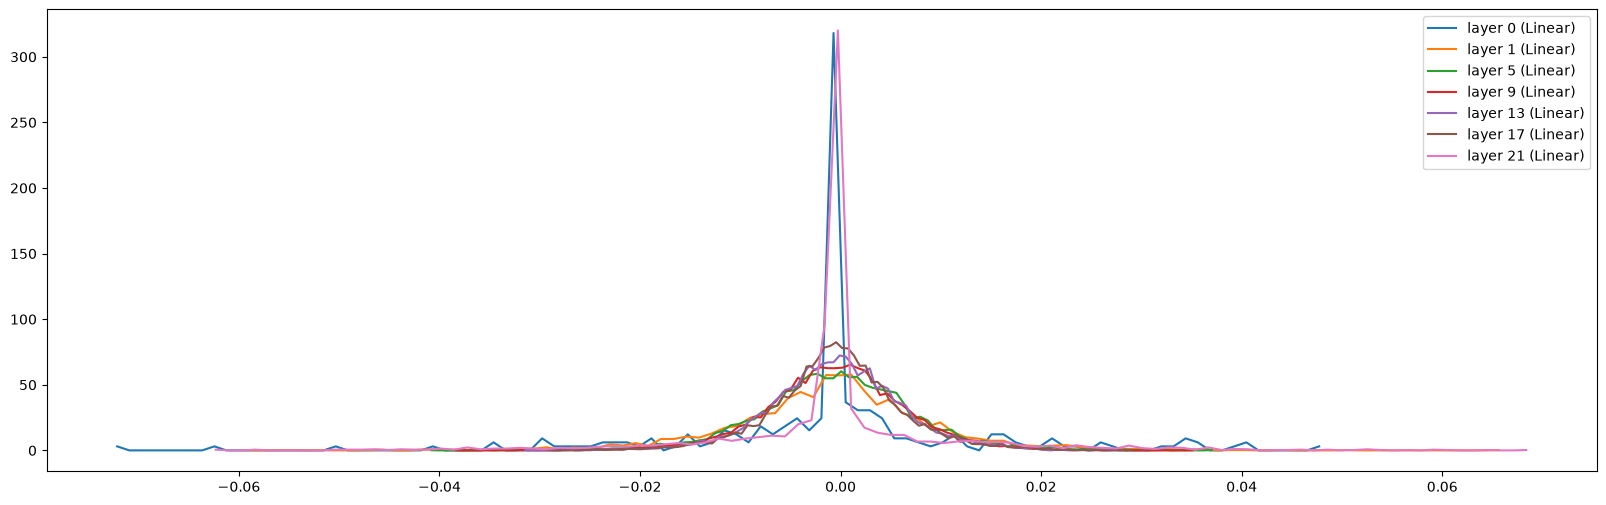

In [40]:
plt.figure(figsize=(20, 6))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print(f"weight {tuple(p.shape)} | mean {+t.mean()} | std {t.std()} | grad:data ratio {t.std() / p.std()}")
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f"layer {i} ({layer.__class__.__name__})")
plt.legend(legends);

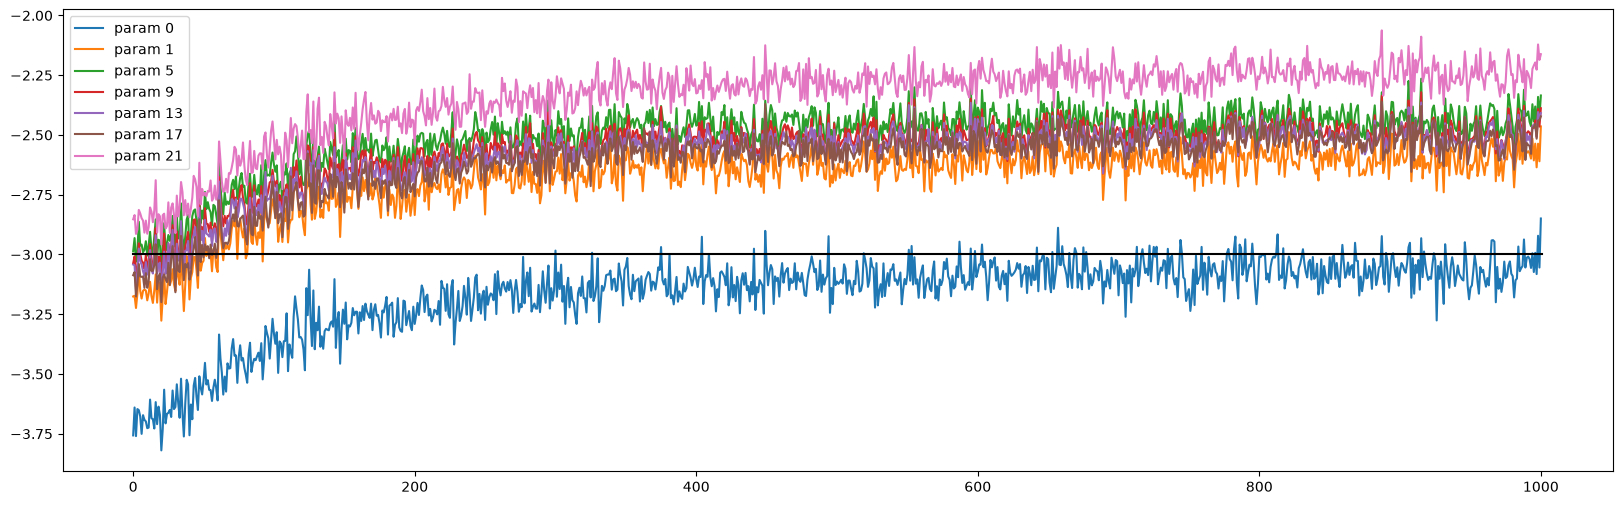

In [41]:
plt.figure(figsize=(20, 6))
legends = []
for i, p in enumerate(parameters):
    if p.ndim == 2:
        plt.plot([ud[j][i] for j in range(len(ud))])
        legends.append(f"param {i}")
plt.plot([0, len(ud)], [-3, -3], "k")
plt.legend(legends);

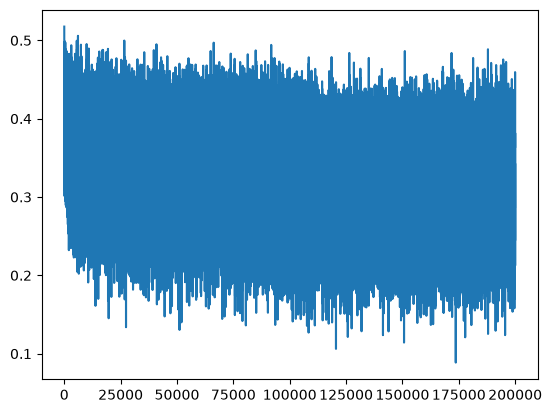

In [ ]:
plt.plot(lossi)

In [ ]:
with torch.no_grad():
    emb = C[Xtr]
    emb_cat = emb.view(emb.shape[0], -1)
    hpreact = emb_cat @ W1 + b1
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [ ]:
@torch.no_grad()
def split_loss(split):

    x, y = {
        "train": (Xtr, Ytr),
        "val": (Xdev, Ydev),
        "test": (Xte, Yte)
    }[split]

    emb = C[x]
    emb_cat = emb.view(emb.shape[0], -1)
    hpreact = emb_cat @ W1 + b1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss("train")
split_loss("val")

train 2.066364288330078
val 2.1214168071746826


In [ ]:
for _ in range(20):

    out = []
    context = [0] * block_size
    while True:

        emb = C[torch.tensor(context)] # shape = (1, block_size, n_embed)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        idx = torch.multinomial(probs, replacement=True, num_samples=1).item()
        context = context[1:] + [idx]
        out.append(idx)
        if idx == 0:
            break

    print("".join(itos[i] for i in out))

cortley.
zakhalilah.
leon.
kalex.
zae.
zeikolynn.
mika.
julie.
blos.
zion.
zohani.
salair.
shelina.
flor.
zaiyah.
jaiver.
jack.
zubiani.
zakaiveryavishawn.
lov.
